In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

root = Path.cwd().parent.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

In [4]:
from src import config

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [6]:
import random, numpy as np, matplotlib.pyplot as plt

In [7]:
random.seed(42)

### ConvEncoder

In [8]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), # Downsample
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Downsample
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # Downsample
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.Flatten() 
        )
        # 128 channels * 8 height * 12 width = 12288
        self.flattened_size = 128 * 8 * 12 #FROM INPUT HEIGHT AND WIDTH
        
        self.mu_layer = nn.Linear(self.flattened_size, latent_dim)
        self.logvar_layer = nn.Linear(self.flattened_size, latent_dim)
        
    def forward(self, x):
        h = self.net(x) # TODO: i dont understand the syntax here
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar       

### ConvDecoder

In [9]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.flattened_size = 128 * 8 * 12
        self.fc = nn.Linear(latent_dim, self.flattened_size)
        
        self.net = nn.Sequential(
            nn.Unflatten(1, (128, 8, 12)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=(1, 0)), # -> 16 x 23
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=(1, 1)), # -> 32 x 46
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=(1, 0)),  # -> 64 x 91
            nn.Sigmoid() 
        )
        
    def forward(self, z):
        h = self.fc(z)
        return self.net(h)

### Conv VAE

In [10]:
class VanillaVAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.config = cfg
        self.encoder = Encoder(
            latent_dim=cfg.LATENT_DIM
        )
        self.decoder = Decoder(
            latent_dim=cfg.LATENT_DIM
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
      x_recon = self.decoder(z)
      return x_recon
  
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

### Dataset Class

In [11]:
class AudioSpectrogramDataset(Dataset):
    def __init__(self, dataset_dir, expected_shape=(config.INPUT_HEIGHT, config.INPUT_WIDTH), add_channel_dim=False):
        super().__init__()
        self.dataset_dir = dataset_dir
        self.file_paths = sorted(self.dataset_dir.rglob("*npy"))
        self.expected_shape = expected_shape
        self.add_channel_dim = add_channel_dim
        self.global_min = -80.0
        self.global_max = 0.0
        
        # mins, maxs = [], []
        # for fp in self.file_paths[:200]:
        #     x = np.load(fp)
        #     mins.append(x.min())
        #     maxs.append(x.max())

        # print("min of mins:", min(mins))
        # print("max of maxs:", max(maxs))
        # print("avg min:", sum(mins)/len(mins))
        # print("avg max:", sum(maxs)/len(maxs))
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, index):
        file_path = self.file_paths[index]
        x = np.load(file_path)
        x = (x - self.global_min) / (self.global_max - self.global_min)
        # x = np.clip(x, 0.0, 1.0)
        x = torch.tensor(x, dtype=torch.float32)
        if self.add_channel_dim: x = x.unsqueeze(0)
        
        return x, str(file_path)

## Activating GPU

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
device

device(type='cuda')

## Train and Test Data Preparation

In [14]:
npy_dir = Path("../..") / config.FEATURES_DIR

In [15]:
dataset = AudioSpectrogramDataset(dataset_dir=npy_dir)

In [16]:
BATCH_SIZE = 32

In [17]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

In [18]:
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [19]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=config.SHUFFLE)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
len(train_dataset), len(test_dataset)

(2000, 500)

## Training and Evaluating

In [21]:
def vae_loss(x_hat, x, beta, mu, logvar, epoch): # required for evaluation
    # recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    beta = min(1.0, epoch / 10)
    total = recon + beta * kl # TODO: use beta when and why?
    
    return total, recon, kl

In [22]:
def train_one_epoch(model, loader, optimizer, beta, epoch, device=device):
    model.train()
    total_sum = recon_sum = kl_sum = n = 0
    
    for x, _ in loader:
        x = x.to(device)
        x = x.unsqueeze(1)
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
        loss.backward()
        optimizer.step()

        total_sum += loss.item()
        recon_sum += recon.item()
        kl_sum += kl.item()
        n += x.size(0) # TODO: = 1 because channel?  
              
    train_total = total_sum / max(n, 1)
    train_recon = recon_sum / max(n, 1)
    train_kl = kl_sum / max(n, 1)
    
    return {
        "loss": train_total,
        "recon": train_recon,
        "kl": train_kl
    }

In [23]:
def evaluate(model, loader, beta, epoch, device=device):
    model.eval()
    total_sum = recon_sum = kl_sum = n = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x = x.unsqueeze(1)
            x_hat, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
            
            total_sum += loss.item()
            recon_sum += recon.item()
            kl_sum += kl.item()
            n += x.size(0)

    test_total = total_sum / max(n, 1)
    test_recon = recon_sum / max(n, 1)
    test_kl = kl_sum / max(n, 1)
    
    return {
        "loss": test_total,
        "recon": test_recon,
        "kl": test_kl
    }

In [24]:
def train_vae(model, train_loader, test_loader, optimizer, beta, device=device):
    history = {"train_total": [], "test_total": [],
               "train_recon": [], "test_recon": [],
               "train_kl": [], "test_kl": []}
    for epoch in range(config.EPOCHS):
        train_stats = train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, beta=beta, epoch=epoch, device=device)
        test_stats = evaluate(model=model, loader=test_loader, beta=beta, epoch=epoch, device=device)
        train_total = train_stats["loss"]
        test_total = test_stats["loss"]
        train_recon = train_stats["recon"]
        test_recon = test_stats["recon"]
        train_kl = train_stats["kl"]
        test_kl = test_stats["kl"]
        history["train_total"].append(train_total)
        history["test_total"].append(test_total)
        history["train_recon"].append(train_recon)
        history["test_recon"].append(test_recon)
        history["train_kl"].append(train_kl)
        history["test_kl"].append(test_kl)
        print(
            f"epoch {epoch:02d} | "
            f"train_total={train_total:.4f} recon={train_recon:.4f} kl={train_kl:.4f} | "
            f"test_total={test_total:.4f} recon={test_recon:.4f} kl={test_kl:.4f}"
        )
        
    return history

In [25]:
def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_total"], label="train total")
    plt.plot(history["test_total"], label="test total")
    plt.plot(history["train_recon"], label="train recon")
    plt.plot(history["test_recon"], label="test recon")
    plt.plot(history["train_kl"], label="train kl")
    plt.plot(history["test_kl"], label="test kl")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

## Single Iteration Model

In [26]:
model = VanillaVAE(cfg=config).to(device)

In [27]:
model

VanillaVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.01)
      (9): Flatten(start_dim=1, end_dim=-1)
    )
    (mu_layer): Linear(in_features=12288, out_features=32, bias=True)
    (logvar_layer): Linear(in_features=12288, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=12288, bias=True)
    (net): Sequential(
     

In [28]:
optimizer = optim.Adam(model.parameters(), lr=config.LR)

In [29]:
history = train_vae(model=model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, beta=50.0, device=device)

epoch 00 | train_total=10.8500 recon=10.8500 kl=93481288.5490 | test_total=7.9510 recon=7.9510 kl=23967504596640.9102
epoch 01 | train_total=3733072372.9891 recon=7.9723 kl=37330723132.4537 | test_total=7934.6662 recon=7.4054 kl=79272.6046
epoch 02 | train_total=1334.0762 recon=7.5090 kl=6632.8363 | test_total=18873.6986 recon=7.2913 kl=94332.0342
epoch 03 | train_total=2937.7686 recon=7.2050 kl=9768.5447 | test_total=34313.7713 recon=7.3274 kl=114354.8048
epoch 04 | train_total=3257.5526 recon=7.0200 kl=8126.3314 | test_total=43014.5040 recon=7.1981 kl=107518.2574
epoch 05 | train_total=4587.2670 recon=6.9128 kl=9160.7085 | test_total=41431.4433 recon=7.0888 kl=82848.7123
epoch 06 | train_total=5382.9210 recon=6.7403 kl=8960.3007 | test_total=65337.2187 recon=7.0074 kl=108883.6836
epoch 07 | train_total=5479.1369 recon=6.5343 kl=7818.0037 | test_total=52510.9488 recon=6.9190 kl=75005.7530
epoch 08 | train_total=5188.5905 recon=6.1912 kl=6477.9990 | test_total=69934.4643 recon=6.6139 k

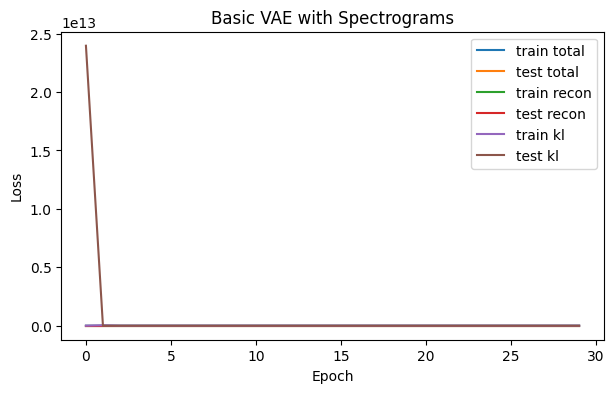

In [30]:
plot_history(history, "Basic VAE with Spectrograms")

## Extract Latent Features & Lyric Embeddings

In [31]:
def show_reconstructions(model, dataset, n=10, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    
    with torch.no_grad():
        for i in range(n):
            # Get a real sample
            print(dataset[i][1])
            x = dataset[i][0].unsqueeze(0).unsqueeze(0).to(device)
            x_hat, _, _ = model(x)
            
            # Original Spectrogram
            img_org = x.squeeze().cpu().numpy()
            axes[i, 0].imshow(img_org, origin='lower', aspect='auto')
            axes[i, 0].set_title(f"Original {i}")
            
            # Reconstructed Spectrogram
            img_recon = x_hat.squeeze().cpu().numpy()
            axes[i, 1].imshow(img_recon, origin='lower', aspect='auto')
            axes[i, 1].set_title(f"Reconstructed {i}")
            
    plt.tight_layout()
    plt.show()

..\..\data\features\MT0002219182_clip_7.npy
..\..\data\features\MT0012505137_clip_7.npy


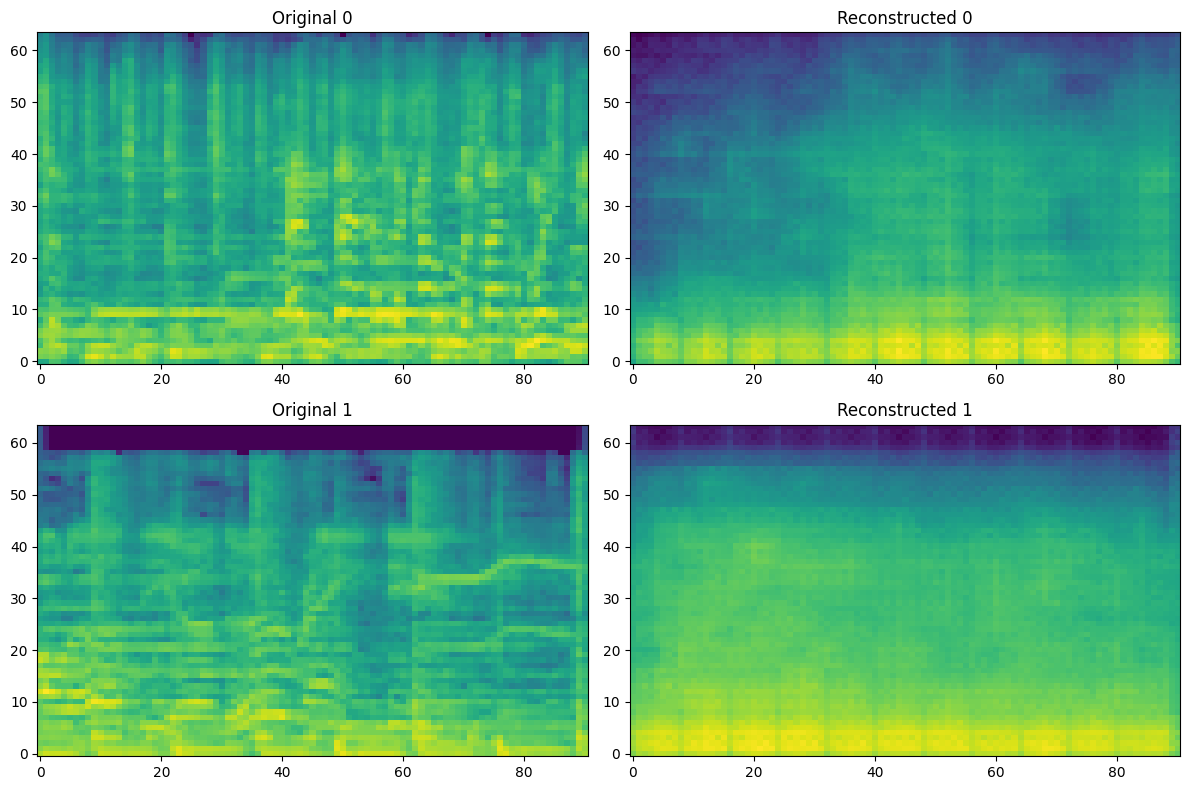

In [32]:
show_reconstructions(model=model, dataset=train_dataset, n=2)

In [33]:
def extract_latents_with_names(model, loader, device=device):
    model.eval()
    latents = []
    names = []
    with torch.no_grad():
        for x, filenames in loader:
            x = x.to(device)
            x = x.unsqueeze(1)
            mu, _ = model.encoder(x)
            latents.append(mu.cpu().numpy())
            names.extend(filenames)
            
    return np.concatenate(latents,axis=0), names

In [34]:
latent_vecs1,audio_names1 = extract_latents_with_names(model=model, loader=train_loader)
latent_vecs2,audio_names2 = extract_latents_with_names(model=model, loader=test_loader)
latent_vecs = np.concatenate([latent_vecs1, latent_vecs2], axis=0)
audio_names = np.concatenate([audio_names1, audio_names2], axis=0)

print(f"Train shape: {latent_vecs1.shape} ")
print(f"Test shape:  {latent_vecs2.shape} ")
print(f"Total shape: {latent_vecs.shape} ")

Train shape: (2000, 32) 
Test shape:  (500, 32) 
Total shape: (2500, 32) 


In [35]:
LYRICS_DATASET_ROOT = Path("C:/Users/User/Downloads/VAE project/MERGE_Lyrics_Balanced") 
LYRIC_FEATURES_DIR = root / "data" / "lyric_features"
print(LYRIC_FEATURES_DIR)

c:\Users\User\Downloads\VAE project\vae-audio-clustering\data\lyric_features


In [36]:
X_hybrid = []

for i, full_name in enumerate(audio_names):
    # 1. Get the parent stem (remove _clip_x)
    parent_stem = full_name.split('_')[0]
    parent_stem = parent_stem.split('\\')[-1]
    # 2. Get the audio vector for this specific row
    z_audio = latent_vecs[i] # Size 32
    
    # 3. Load the corresponding lyric vector
    # We use the parent_stem to find the lyric file
    lyric_path = LYRIC_FEATURES_DIR / f"{parent_stem}.npy"
    # print(lyric_path)
    
    if lyric_path.exists():
        z_text = np.load(lyric_path) # Size 384
        
        # 4. Concatenate: [32] + [786] = [800]
        z_combined = np.concatenate([z_audio, z_text])
        X_hybrid.append(z_combined)
    else:
        print(f"Warning: No lyrics for {parent_stem}")

X_hybrid = np.array(X_hybrid)

In [37]:
X_hybrid.shape

(2500, 800)

## K-means of Latent Features (Conv VAE Model for Easy Task)

In [38]:
X_hybrid

array([[ 0.48992062, -0.22599779, -0.41861522, ...,  0.01906769,
        -0.00820425, -0.04146567],
       [ 1.5964782 , -0.81545526, -0.28248698, ...,  0.0208964 ,
         0.01471075, -0.00616673],
       [ 0.9400246 , -0.55182093, -0.5434892 , ..., -0.00349812,
         0.01114061, -0.01388543],
       ...,
       [ 1.3048998 ,  0.05635294,  0.05885467, ..., -0.01020224,
        -0.02948025, -0.02896471],
       [ 0.38031906,  0.43080854,  0.07678652, ..., -0.00647722,
         0.0247005 , -0.01813705],
       [ 1.4443494 , -0.45306325, -0.14339644, ...,  0.00570591,
        -0.01219231,  0.01913879]], shape=(2500, 800), dtype=float32)

In [39]:
import pandas as pd
X_hybrid=pd.DataFrame(X_hybrid )
X_hybrid.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799
0,0.489921,-0.225998,-0.418615,-0.706167,-1.519116,-0.253134,0.300465,-0.389206,0.289053,1.626259,-0.655737,0.809072,0.328381,0.463506,-1.884219,0.530460,0.266357,-1.078025,-0.324017,-0.607979,0.649162,0.222367,-0.861863,0.409063,1.130402,-0.809539,-0.146972,-0.342287,0.903601,0.086458,-0.390718,-0.903063,0.045320,0.059654,0.008710,0.004054,-0.004892,0.032164,-0.028045,0.010926,...,-0.006173,0.038838,0.019016,-0.015236,-0.041778,0.011761,0.016821,-0.000851,-0.018589,0.065484,0.015846,0.027411,0.035163,-0.058988,-0.002731,0.034191,-0.034888,0.089727,-0.028833,0.054778,0.070141,0.025487,0.053850,-0.001124,-0.062015,-0.000199,-0.058938,-0.055246,3.125910e-34,0.011821,0.007426,0.041807,-0.021457,-0.024956,-0.013945,0.005708,0.024745,0.019068,-0.008204,-0.041466
1,1.596478,-0.815455,-0.282487,-0.050208,-2.020627,0.513630,0.535889,-0.460020,-0.312280,0.461011,-0.136881,1.767631,0.527094,-0.575269,3.560889,0.347925,1.536254,0.574951,-2.541630,-1.859460,0.604299,0.211639,-0.610121,1.460430,0.223387,0.014701,0.165761,1.162927,0.161779,-0.013919,0.238885,-0.598128,-0.004156,0.050675,0.043599,0.004885,-0.027520,0.038936,-0.016361,-0.022648,...,0.073763,-0.008996,0.034301,0.000662,-0.020293,-0.008724,0.039460,-0.026862,-0.045598,0.036735,0.013620,-0.020251,0.000328,-0.066451,-0.083350,-0.042275,-0.026408,0.016569,-0.058469,0.014610,0.020453,-0.011918,0.062849,0.014991,0.025445,-0.005772,-0.019465,0.000620,2.135227e-34,0.068330,-0.016960,-0.020220,0.006526,-0.026686,-0.015287,-0.040598,-0.054714,0.020896,0.014711,-0.006167
2,0.940025,-0.551821,-0.543489,-0.781280,-1.706774,0.349919,0.406525,-0.729623,0.320788,1.472536,-0.964461,1.315955,0.878261,-0.159580,-1.358599,1.419261,0.741752,-1.676617,-1.723142,-0.347451,1.215126,-0.070459,-0.655072,0.601591,1.646465,-0.538549,-0.082764,0.526720,0.873685,-0.070346,-0.227082,-1.096766,0.003693,0.062377,0.009281,0.003135,-0.040052,0.029377,-0.045359,-0.012280,...,0.065731,0.026402,-0.014189,-0.020555,-0.061426,0.006855,0.024617,0.007156,-0.011256,-0.012389,0.037615,0.021396,0.044621,-0.029346,0.017834,0.042176,-0.000555,0.057026,-0.046896,0.008480,0.044874,0.014053,0.029236,-0.003521,0.027296,0.005628,-0.012665,-0.030326,3.117586e-34,0.036868,-0.058294,-0.015145,0.022493,-0.004712,-0.017098,0.058575,-0.010002,-0.003498,0.011141,-0.013885
3,0.006152,-0.559572,-0.270419,0.626243,-2.362487,0.923333,-0.157392,-0.696146,-0.513891,0.450376,-0.305552,1.352919,0.745800,-1.204697,0.112923,-0.683631,1.229017,-0.533858,0.002940,-2.275913,3.025689,-0.373781,-0.864764,0.828584,1.111814,0.674677,1.168109,1.389007,-1.280890,0.069290,0.821461,-0.134301,-0.000433,-0.005105,0.001610,-0.016091,-0.008327,0.002245,-0.010845,0.014107,...,0.070263,0.007355,0.034513,0.024018,0.015087,0.043083,-0.025464,-0.032363,0.048241,0.022947,0.021559,0.015182,-0.024161,-0.094340,-0.019238,-0.016181,-0.058062,0.023040,0.001130,0.039018,-0.050842,0.017408,-0.025047,0.017940,-0.017951,0.027648,0.029930,-0.021418,1.195310e-34,0.051122,-0.107609,0.077595,0.044266,-0.006920,-0.030297,-0.028369,0.007412,-0.018505,-0.015172,-0.033966
4,0.627857,-0.325790,-0.257014,-0.746085,-1.428617,-0.339922,1.272953,-0.677630,-0.345100,1.403688,-0.540739,0.509952,-0.199544,0.287467,0.436950,0.706291,0.601355,-0.394189,-0.696531,-1.279096,0.281416,-0.375936,-0.711202,1.200121,1.195200,-0.507500,0.062979,-0.414142,1.167342,0.061901,-0.088650,-1.241500,0.017042,0.017584,-0.002518,-0.013051,-0.005542,0.000818,-0.027625,-0.055063,...,0.021240,-0.026192,0.026587,0.000689,-0.029705,0.018759,-0.024087,-0.047366,0.003851,0.063438,0.019425,0.003009,-0.031183,-0.080106,-0.020293,-0.050048,0.006962,0.025752,0.014243,0.027318,0.034966,-0.011446,0.011839,0.064588,0.042207,-0.006124,-0.012870,-0.037935

In [40]:
X_hybrid.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2.500000e+03,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,0.748300,-0.135396,0.028803,-0.157107,-0.350062,0.327718,0.385283,-0.199932,0.180889,0.310217,-0.074921,0.294410,-0.211097,0.477237,-0.065102,0.259880,0.485242,-0.183946,-0.989203,-0.747041,-0.019937,-0.245491,-0.224559,-0.039478,0.524321,-0.097779,0.014017,0.377596,0.099217,0.039353,-0.064012,-0.283623,0.018604,0.036132,0.001721,-0.013082,-0.017442,0.016752,-0.021887,-0.020183,...,0.014702,-0.006797,0.010101,0.004442,-0.026301,0.011571,-0.004177,-0.018075,0.001331,0.020647,0.008222,0.003084,-0.008828,-0.045105,-0.030115,-0.020926,-0.014898,0.028631,-0.028841,0.022990,0.023513,0.008338,0.027073,0.020618,0.038967,0.005244,-0.035364,-0.012636,2.160010e-34,0.035401,-0.025838,-0.002853,0.012728,0.001246,-0.017044,-0.003480,-0.033128,-0.004572,-0.022492,-0.014866
std,0.503136,0.280804,0.319144,0.357043,0.831180,0.432696,0.590561,0.247958,0.399652,0.791741,0.416105,0.590424,0.657132,0.846559,1.478598,0.621978,0.460375,0.652446,1.076265,0.765129,0.795999,0.395870,0.569259,0.726590,0.595485,0.340385,0.270030,0.623244,0.589284,0.091784,0.374388,0.455831,0.028572,0.035463,0.017401,0.026802,0.026796,0.024036,0.033298,0.025064,...,0.035412,0.028128,0.032941,0.021892,0.031762,0.021862,0.041939,0.023551,0.034161,0.031685,0.024435,0.025862,0.030167,0.028008,0.031366,0.028645,0.026666,0.021867,0.025657,0.023666,0.037207,0.025976,0.031017,0.024385,0.033554,0.029420,0.040327,0.024394,0.000000e+00,0.022530,0.031742,0.025370,0.033978,0.023234,0.016178,0.035347,0.025087,0.023957,0.031803,0.020952
min,-1.701273,-1.575127,-1.185844,-1.372959,-4.045891,-1.605981,-2.994499,-1.041038,-2.116715,-2.208786,-1.594199,-2.666351,-2.309806,-3.087653,-2.879437,-2.346498,-1.276592,-3.130565,-5.898201,-4.627007,-2.909187,-1.950788,-2.027061,-2.721869,-4.048062,-1.693700,-0.857637,-1.823830,-2.916030,-0.369831,-2.292672,-1.681996,-0.073997,-0.077061,-0.053204,-0.087728,-0.109233,-0.067816,-0.129996,-0.106022,...,-0.113215,-0.103413,-0.104680,-0.069429,-0.119506,-0.056325,-0.131417,-0.083594,-0.141556,-0.095790,-0.093665,-0.084725,-0.094016,-0.125664,-0.128352,-0.119293,-0.095774,-0.042665,-0.105971,-0.057017,-0.101836,-0.106935,-0.097496,-0.083240,-0.076512,-0.093285,-0.159247,-0.089746,8.209842e-35,-0.050101,-0.123760,-0.083610,-0.097509,-0.105466,-0.070846,-0.144655,-0.111684,-0.080749,-0.110829,-0.082614
25%,0.408797,-0.315945,-0.183446,-0.344817,-0.859312,0.053926,0.068195,-0.357303,-0.026976,-0.243617,-0.335388,-0.132162,-0.672229,0.004889,-1.237501,-0.132888,0.167382,-0.541908,-1.557703,-1.187680,-0.608354,-0.474787,-0.587595,-0.473360,0.252898,-0.295853,-0.155089,0.000456,-0.228327,-0.011845,-0.302584,-0.535507,-0.000213,0.011360,-0.009742,-0.030559,-0.035622,0.001567,-0.043561,-0.036818,...,-0.008275,-0.025161,-0.011020,-0.01016

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

%matplotlib inline

In [42]:
track_inertia={}
silhouette={}
ch_index={}
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init = 'k-means++', random_state=42)
    kmeans.fit(X_hybrid)
    track_inertia[k] = kmeans.inertia_
    silhouette[k] = silhouette_score(X_hybrid, kmeans.labels_) 
    ch_index[k] = calinski_harabasz_score(X_hybrid, kmeans.labels_)

<Axes: >

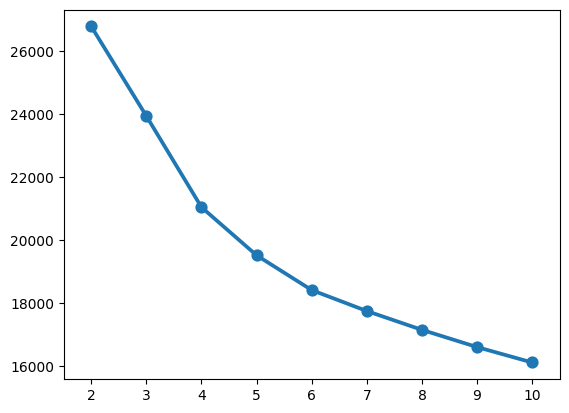

In [43]:
sns.pointplot(x = list(track_inertia.keys()), y = list(track_inertia.values()))

<Axes: >

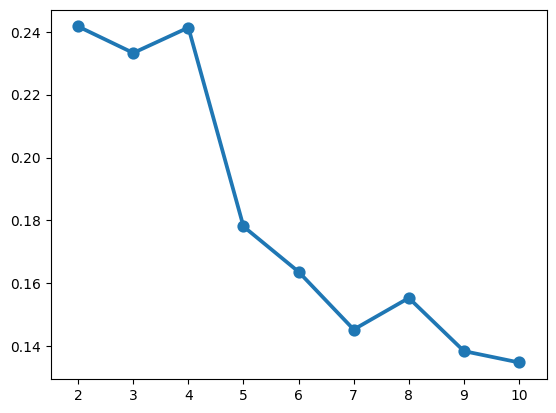

In [44]:
sns.pointplot(x = list(silhouette.keys()), y = list(silhouette.values()))

<Axes: >

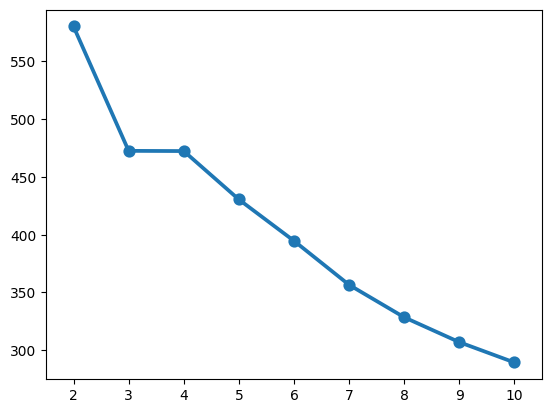

In [45]:
sns.pointplot(x = list(ch_index.keys()), y = list(ch_index.values()))

In [ ]:
wcss = []
k_values = range(1, 12)

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=0)
    km.fit(X_hybrid)
    wcss.append(km.inertia_) # inertia_ is the "WCSS" value you need for the elbow


plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method (Manual)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

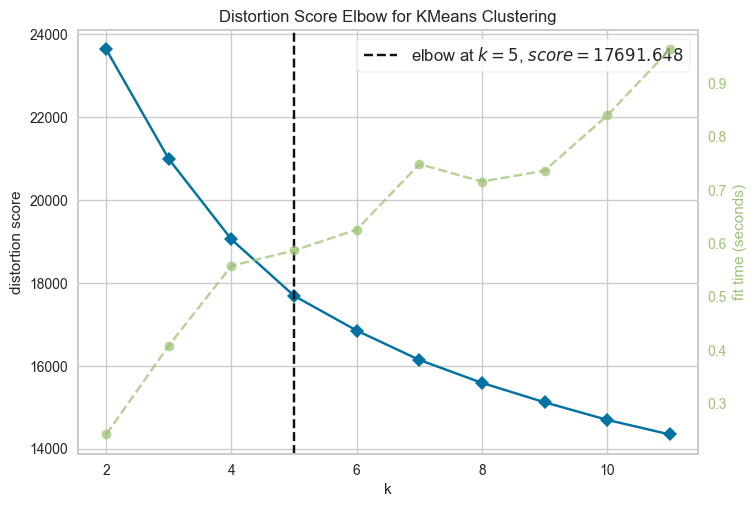

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model2 = KMeans(init='k-means++', random_state=0, n_init=10)

visualizer = KElbowVisualizer(model2, k=(2, 12), timings=True, force_model=True)

visualizer.fit(X_hybrid)        
visualizer.show()

optimal_k = visualizer.elbow_value_

In [ ]:
optimal_k

np.int64(5)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = optimal_k,init = "k-means++",max_iter = 300,n_init=10,random_state=0)
kmeans.fit(X_hybrid)
vae_clusters = kmeans.predict(X_hybrid)
vae_sil_kmeans=silhouette_score(X_hybrid,kmeans.labels_)
vae_dav_kmeans = davies_bouldin_score(X_hybrid, kmeans.labels_)
print("Silhouette Score: %f"%(kmeans.inertia_,vae_sil_kmeans))
print("Davies Bouldin Score: %f"%(kmeans.inertia_,vae_dav_kmeans))

NameError: name 'optimal_k' is not defined

In [ ]:
from sklearn.cluster import DBSCAN
# eps: The maximum distance between two samples for them to be considered as in the same neighborhood
# min_samples: The number of samples in a neighborhood for a point to be a core point
dbscan = DBSCAN(eps=0.5, min_samples=5) 
vae_clusters_db = dbscan.fit_predict(X_hybrid)
# Note: DBSCAN labels noise as -1. Silhouette score requires at least 2 clusters (excluding noise).
n_clusters_ = len(set(vae_clusters_db)) - (1 if -1 in vae_clusters_db else 0)

if n_clusters_ > 1:
    vae_sil_db = silhouette_score(X_hybrid, vae_clusters_db)
    vae_dav_db = davies_bouldin_score(X_hybrid, vae_clusters_db)
    print(f"DBSCAN Clusters found: {n_clusters_}")
    print(f"Silhouette Score: {vae_sil_db:.4f}")
    print(f"Calinski-Harabasz Score: {vae_ch_db:.4f}")
else:
    print("DBSCAN only found 1 cluster or noise. Try adjusting 'eps'.")

## PCA + Kmeans (Baseline Model for Easy Task)

In [ ]:
def loader_to_numpy(loader):
    xs = []
    for x,_ in loader:
        xs.append(x.view(x.size(0), -1).numpy())
    return np.concatenate(xs)

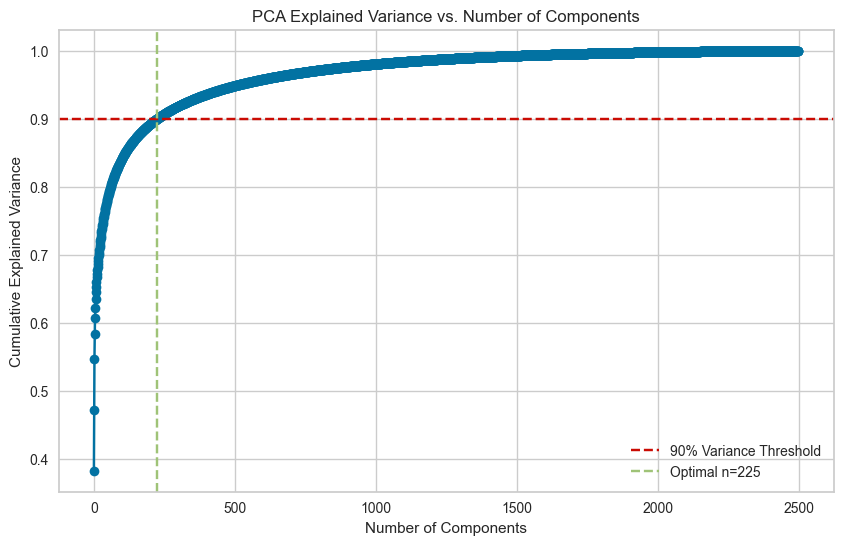

Optimal components for 90% variance: 225


In [ ]:
from sklearn.decomposition import PCA

X_train = loader_to_numpy(train_loader)
X_test = loader_to_numpy(test_loader)

X_all = np.concatenate([X_train, X_test], axis=0)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca_full = PCA().fit(X_all)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
optimal_n = np.where(cumulative_variance >= 0.90)[0][0] + 1

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='-') # removed 'loc'
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.axvline(x=optimal_n, color='g', linestyle='--', label=f'Optimal n={optimal_n}')
plt.title('PCA Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print(f"Optimal components for 90% variance: {optimal_n}")

In [ ]:
optimal_n

np.int64(225)

In [ ]:
pca = PCA(n_components=optimal_n, random_state=42)
X_pca = pca.fit_transform(X_all)

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
pca_clusters = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, pca_clusters)
ch_idx = calinski_harabasz_score(X_pca, pca_clusters)

print(f"--- PCA + KMeans Baseline ---")
print(f"Silhouette Score: {round(sil, 4)}")
print(f"Calinski-Harabasz Index: {round(ch_idx, 4)}")

--- PCA + KMeans Baseline ---
Silhouette Score: 0.174
Calinski-Harabasz Index: 485.385


## Visualize t-sne for both models

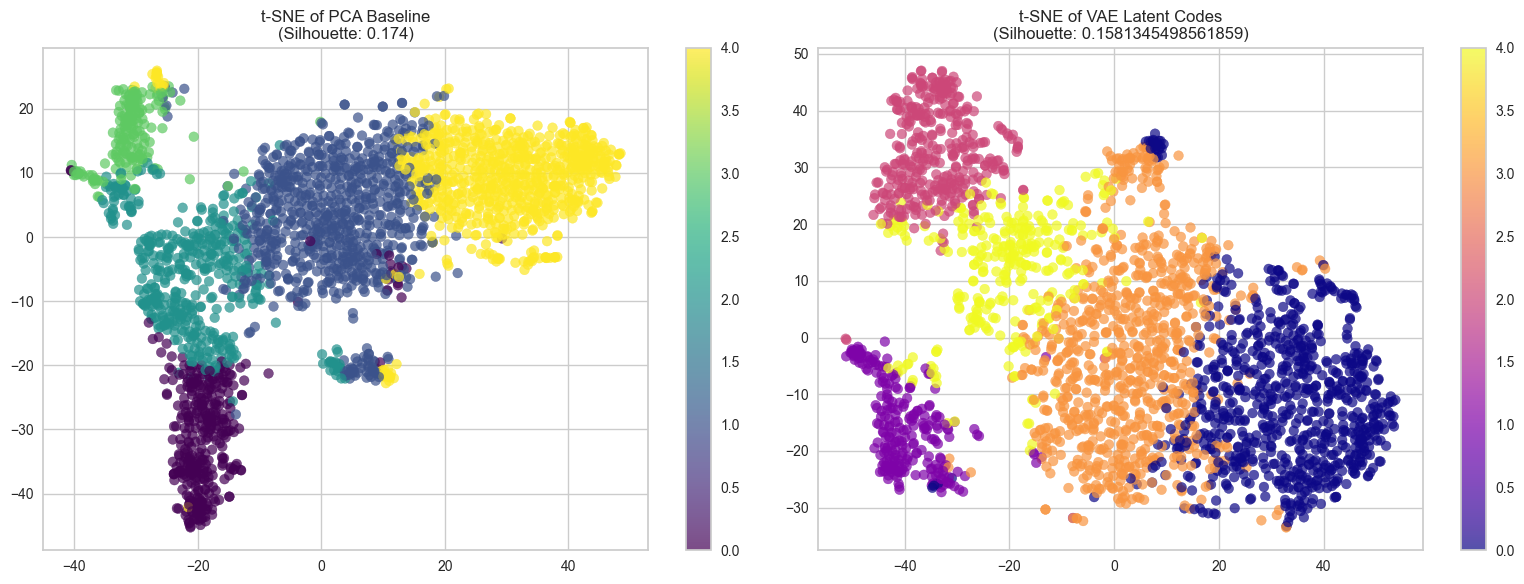

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_comparison(pca_latents, vae_latents, pca_clusters, vae_clusters):

    tsne_pca = TSNE(n_components=2, random_state=42).fit_transform(pca_latents)
    
    tsne_vae = TSNE(n_components=2, random_state=42).fit_transform(vae_latents)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    scatter1 = ax1.scatter(tsne_pca[:, 0], tsne_pca[:, 1], c=pca_clusters, cmap='viridis', alpha=0.7)
    ax1.set_title(f"t-SNE of PCA Baseline\n(Silhouette: {round(sil, 4)})")
    fig.colorbar(scatter1, ax=ax1)
    
    scatter2 = ax2.scatter(tsne_vae[:, 0], tsne_vae[:, 1], c=vae_clusters, cmap='plasma', alpha=0.7)
    ax2.set_title(f"t-SNE of VAE Latent Codes\n(Silhouette: {vae_sil})")
    fig.colorbar(scatter2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

plot_tsne_comparison(X_pca, latent_vecs, pca_clusters, vae_clusters)